In [1]:
import os
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading Dermnet Dataset... (Larger dataset, may take 1-2 mins)")
# using the 'shubhamgoel27/dermnet' dataset which is well structured
!kaggle datasets download -d shubhamgoel27/dermnet
!unzip -q dermnet.zip

print("Download & Unzip Complete!")
#no organizing script is needed.
import os
num_classes = len(os.listdir('train'))
print(f"Detected {num_classes} different skin conditions!")

⬇️ Downloading Dermnet Dataset... (Larger dataset, may take 1-2 mins)
Dataset URL: https://www.kaggle.com/datasets/shubhamgoel27/dermnet
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 99% 1.70G/1.72G [00:17<00:00, 380MB/s]
100% 1.72G/1.72G [00:17<00:00, 105MB/s]
✅ Download & Unzip Complete!
✨ Detected 23 different skin conditions!


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# Lower batch size reduces RAM usage (try 16, or 8 if it still crashes)
BATCH_SIZE = 16
IMG_SIZE = (224, 224)

print("Loading training data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    'train',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int' # more efficient than 'categorical' for sparse loss
)

print("Loading validation data...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    'test',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Training on {num_classes} classes.")

# REMOVED .cache() to prevent RAM explosion keeping prefetch, manageable amount.
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# 2. Build Model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

# 3. Train
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Starting Low-RAM Training...")
# Since we removed cache, one epoch might be slightly slower, but it won't crash.
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

# 4. Save
model.save('skin_model.keras')
print("Model saved!")

print("\n" + "="*50)
print("CLASS NAMES")
print(class_names)
print("="*50)

📂 Loading training data...
Found 15557 files belonging to 23 classes.
📂 Loading validation data...
Found 4002 files belonging to 23 classes.
🧠 Training on 23 classes.
🚀 Starting Low-RAM Training...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


973/973 ━━━━━━━━━━━━━━━━━━━━ 103s 88ms/step - accuracy: 0.2143 - loss: 2.8209 - val_accuracy: 0.3271 - val_loss: 2.3336
Epoch 2/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 49s 50ms/step - accuracy: 0.3280 - loss: 2.2684 - val_accuracy: 0.3461 - val_loss: 2.2650
Epoch 3/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.3661 - loss: 2.1259 - val_accuracy: 0.3521 - val_loss: 2.2283
Epoch 4/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 48s 50ms/step - accuracy: 0.3874 - loss: 2.0590 - val_accuracy: 0.3436 - val_loss: 2.2509
Epoch 5/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 47s 49ms/step - accuracy: 0.3943 - loss: 2.0014 - val_accuracy: 0.3618 - val_loss: 2.2040
Epoch 6/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.4038 - loss: 1.9691 - val_accuracy: 0.3723 - val_loss: 2.1902
Epoch 7/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - accuracy: 0.4120 - loss: 1.9494 - val_accuracy: 0.3611 - val_loss: 2.2224
Epoch 8/15
973/973 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.4203 - loss: 1.9212 - val_accura

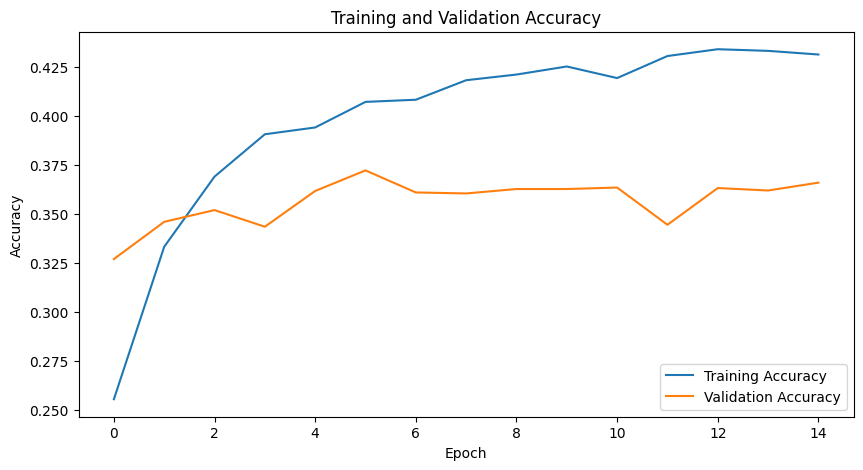

In [2]:
import matplotlib.pyplot as plt

# Get training and validation accuracy from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [4]:
print(f"Final Training Accuracy: {acc[-1]*100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1]*100:.2f}%")

Final Training Accuracy: 43.14%
Final Validation Accuracy: 36.61%
